# Scene Graph Generation from RoboFail Video Recordings

**Tim**

This notebook walks through each stage of generating a textual scene graph summary from a RoboFail dataset video. The original pipeline was built for real-world robot sensor data (RGB-D + telemetry from a RealSense camera); here I adapt it to work on video files only — extracting frames, estimating depth monocularly, detecting objects with MDETR + CLIP, building spatial scene graphs, and producing the hierarchical L1/L2 text summaries that feed into an LLM for failure reasoning.

The reader can expect a step-by-step walkthrough: each cell does one thing, prints its output, and the markdown in between explains *why* that step exists.

### Background

The RoboFail dataset contains video recordings of robotic manipulation tasks — some successful, some ending in failure. Each recording captures an egocentric view of the robot's workspace and optionally includes audio. A companion task JSON provides metadata: the task name, the object list, action stage boundaries, and ground-truth failure annotations.

The goal is to convert these raw videos into structured scene graph summaries at two levels of abstraction (L1 = per-keyframe, L2 = per-action) that an LLM can consume to reason about *what went wrong* and *at which step*.

The original pipeline assumes a RealSense RGB-D camera, zarr-packed sensor recordings, and live gripper telemetry. Since RoboFail provides only video, I need to:

1. Extract RGB frames from the MP4 via OpenCV
2. Estimate depth with a monocular model (Depth Anything V2) — or fall back to 2D-only scene graphs
3. Extract audio via ffmpeg for AudioCLIP sound detection
4. Replace gripper-state logic (unavailable from video)

### References

- [RoboFail dataset](https://github.com/arpitrf/RoboFail) — source of the video recordings
- [MDETR](https://github.com/ashkamath/mdetr) — modulated detection for end-to-end multi-modal understanding
- [Depth Anything V2](https://github.com/DepthAnything/Depth-Anything-V2) — monocular depth estimation
- [AudioCLIP](https://github.com/AndreyGuzhov/AudioCLIP) — audio event classification

In [1]:
# standard library
import os
import json
import pickle
import subprocess
from pathlib import Path
from collections import defaultdict

# third-party
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torchvision.transforms as T

# device + seed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(91)
np.random.seed(91)
print(f"Device: {device}")

Device: cuda


### Path constants

All paths are defined once here using `pathlib.Path` so nothing is hard-coded deeper in the notebook. Adjust `VIDEO_PATH` and `TASK_JSON_PATH` to point at your RoboFail recording; everything else derives from `OUTPUT_DIR`.

In [ ]:
# ── Input paths (adjust these to your setup) ──
data_dir = Path("/home/coder/datasets")
VIDEO_PATH     = data_dir / "real_data" / "appleInFridge1" / "videos" / "color.mp4"
TASK_JSON_PATH = data_dir / "tasks_real_world.json"

# ── Output root ──
OUTPUT_DIR = Path("robofail_output") / VIDEO_PATH.stem
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Derived output paths ──
FRAMES_DIR       = OUTPUT_DIR / "frames"
DEPTH_DIR        = OUTPUT_DIR / "depth"
LOCAL_GRAPHS_DIR = OUTPUT_DIR / "local_graphs"
DET_DIR          = OUTPUT_DIR / "mdetr_obj_det" / "det"
CLIP_DET_DIR     = OUTPUT_DIR / "mdetr_obj_det" / "clip_processed_det"
AUDIO_PATH       = OUTPUT_DIR / "audio.wav"
GLOBAL_SG_PATH   = OUTPUT_DIR / "global_sg.pkl"
L1_SUMMARY_PATH  = OUTPUT_DIR / "state_summary_L1.txt"
L2_SUMMARY_PATH  = OUTPUT_DIR / "state_summary_L2.txt"
KEYFRAMES_PATH   = OUTPUT_DIR / "L1_key_frames.txt"

for d in [FRAMES_DIR, DEPTH_DIR, LOCAL_GRAPHS_DIR, DET_DIR, CLIP_DET_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Video:      {VIDEO_PATH}")
print(f"Task JSON:  {TASK_JSON_PATH}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"All subdirectories created.")

Video:      /home/coder/datasets/sim_data/boilWater/boilWater-1/original-video.mp4
Task JSON:  /home/coder/datasets/sim_data/boilWater/boilWater-1/task.json
Output dir: robofail_output/original-video
All subdirectories created.


### Load task metadata

The task JSON tells us what objects to detect, what actions the robot performed, and what the ground-truth failure is. If no JSON exists (e.g. unannotated video), the pipeline still works — it just won't have action labels in the summaries.

In [3]:
task_info = None
if TASK_JSON_PATH.exists():
    task_info = json.loads(TASK_JSON_PATH.read_text())
    print(f"Task name:        {task_info.get('name', 'N/A')}")
    print(f"Object list:      {task_info.get('object_list', [])}")
    print(f"GT failure step:  {task_info.get('gt_failure_step', 'N/A')}")
    print(f"GT failure reason: {task_info.get('gt_failure_reason', 'N/A')}")
else:
    print(f"No task JSON found at {TASK_JSON_PATH} — running without annotations.")

# Fall back to a manual object list if none in JSON
OBJECT_LIST = task_info.get("object_list", []) if task_info else []
if not OBJECT_LIST:
    OBJECT_LIST = ["mug", "faucet", "sink", "pot"]
    print(f"Using default object list: {OBJECT_LIST}")

DISTRACTOR_LIST = task_info.get("distractor_list", []) if task_info else []
print(f"Distractor list:  {DISTRACTOR_LIST}")

Task name:        boil water
Object list:      ['Pot', 'Faucet', 'StoveBurner', 'CounterTop', 'Sink']
GT failure step:  00:36
GT failure reason: Dropped Pot
Distractor list:  []


### Open video and extract metadata

I use OpenCV's `VideoCapture` to read the MP4. The key numbers I need are the total frame count, FPS (for timestamp conversion), and the resolution (for pseudo camera intrinsics later).

In [4]:
cap = cv2.VideoCapture(str(VIDEO_PATH))
assert cap.isOpened(), f"Cannot open video: {VIDEO_PATH}"

TOTAL_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
FPS          = cap.get(cv2.CAP_PROP_FPS)
WIDTH        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
HEIGHT       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
DURATION_SEC = TOTAL_FRAMES / FPS if FPS > 0 else 0

print(f"Frames:     {TOTAL_FRAMES}")
print(f"FPS:        {FPS:.1f}")
print(f"Resolution: {WIDTH}x{HEIGHT}")
print(f"Duration:   {DURATION_SEC:.1f}s ({DURATION_SEC/60:.1f}min)")

Frames:     49
FPS:        1.0
Resolution: 960x960
Duration:   49.0s (0.8min)


### Pseudo camera intrinsics

The original pipeline uses hardcoded RealSense intrinsics for back-projecting depth to 3D point clouds. Since we don't know the exact camera that recorded the RoboFail video, I approximate with `focal_length ≈ image_width` (roughly 90° horizontal FoV) and the principal point at the image centre.

If your simulator or camera has known intrinsics, replace this cell.

In [5]:
fx = fy = float(WIDTH)
cx, cy = WIDTH / 2.0, HEIGHT / 2.0

INTRINSICS = np.array([
    [fx,  0.0, cx ],
    [0.0, fy,  cy ],
    [0.0, 0.0, 1.0],
])

print("Camera intrinsics (pseudo):")
print(INTRINSICS)

Camera intrinsics (pseudo):
[[960.   0. 480.]
 [  0. 960. 480.]
 [  0.   0.   1.]]


### Frame reading helper

A small utility to grab a specific frame by index and convert BGR → RGB (OpenCV loads BGR, but the rest of the pipeline — MDETR, CLIP, PIL — expects RGB).

Frame 0 shape: (960, 960, 3), dtype: uint8


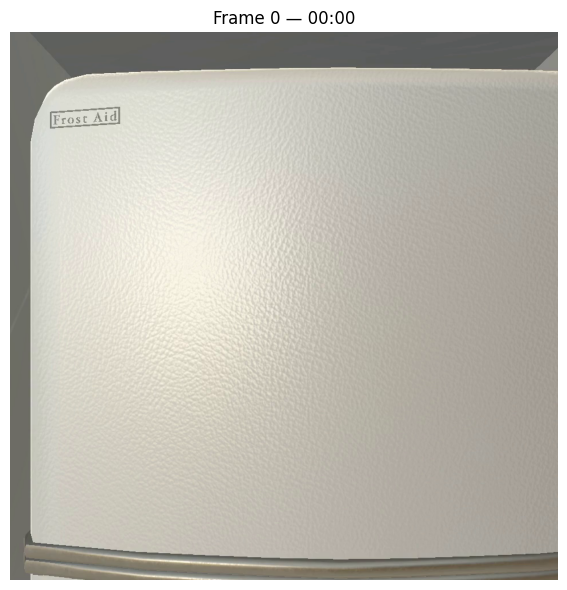

In [10]:
def read_frame(cap: cv2.VideoCapture, frame_idx: int) -> np.ndarray:
    """Read a single RGB frame from the video."""
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, bgr = cap.read()
    if not ret:
        raise IndexError(f"Could not read frame {frame_idx}")
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def frame_to_timestamp(frame_idx: int, fps: float) -> str:
    """Convert frame index to MM:SS string."""
    secs = frame_idx / fps if fps > 0 else 0
    return f"{int(secs // 60):02d}:{int(secs % 60):02d}"


# Quick sanity check — read and display the first frame
sample_rgb = read_frame(cap, 0)
print(f"Frame 0 shape: {sample_rgb.shape}, dtype: {sample_rgb.dtype}")

plt.figure(figsize=(10, 6))
plt.imshow(sample_rgb)
plt.title(f"Frame 0 — {frame_to_timestamp(0, FPS)}")
plt.axis("off")
plt.tight_layout()
plt.show()

### Audio extraction

The original pipeline feeds a `.wav` file to AudioCLIP for sound event detection (e.g. "something drops", "toggle on faucet"). Since RoboFail videos embed audio in the MP4 container, I extract it with ffmpeg. If the video has no audio track or ffmpeg isn't installed, this step is skipped gracefully.

In [12]:
def extract_audio(video_path: Path, output_path: Path) -> bool:
    """Extract mono 44.1kHz WAV from video. Returns True on success."""
    if output_path.exists():
        print(f"Audio already extracted: {output_path}")
        return True
    try:
        result = subprocess.run(
            ["ffmpeg", "-i", str(video_path),
             "-vn", "-acodec", "pcm_s16le", "-ar", "44100", "-ac", "1",
             str(output_path), "-y"],
            capture_output=True, text=True, timeout=120,
        )
        if result.returncode == 0 and output_path.exists():
            print(f"Audio extracted: {output_path} ({output_path.stat().st_size / 1024:.0f} KB)")
            return True
        else:
            print(f"ffmpeg failed: {result.stderr[:200]}")
            return False
    except FileNotFoundError:
        print("ffmpeg not found — skipping audio extraction.")
        return False


has_audio = extract_audio(VIDEO_PATH, AUDIO_PATH)

Audio extracted: robofail_output/original-video/audio.wav (4221 KB)


### Sound event detection (AudioCLIP)

If audio was extracted successfully and AudioCLIP is available, I detect sound events and map them to frame indices. Each detected sound gets attached to the nearest frame at `timestamp × FPS`.

If AudioCLIP is not installed, the pipeline continues without auditory observations — the scene graphs and L1/L2 summaries will just lack the "Auditory observation" lines.

In [13]:
sound_det_idx_dict = {}

try:
    from AudioCLIP.real_world_audio import get_sound_events

    if has_audio:
        detected_sounds = get_sound_events(audio_path=str(AUDIO_PATH), volume_thresh=0.04)
        for (start_sec, end_sec), label in detected_sounds.items():
            frame_idx = int(end_sec * FPS)
            sound_det_idx_dict[frame_idx] = label
        print(f"Detected {len(sound_det_idx_dict)} sound events:")
        for idx, label in sorted(sound_det_idx_dict.items()):
            print(f"  Frame {idx} ({frame_to_timestamp(idx, FPS)}): {label}")
    else:
        print("No audio available — skipping sound detection.")
except ImportError:
    print("AudioCLIP not installed — skipping sound detection.")

print(f"\nSound events to include: {len(sound_det_idx_dict)}")

AudioCLIP not installed — skipping sound detection.

Sound events to include: 0


### Parse action boundaries from task JSON

The original pipeline reads `data/stage` from the zarr replay buffer to know when each robot action starts and ends. For RoboFail videos, I parse this from the task JSON instead. I support three common annotation formats and fall back to empty if none match.

These boundaries serve two purposes: they define which frames to always include (action endpoints), and they provide the "Action: PickupObject" labels in the L1/L2 summaries.

In [ ]:
def parse_action_boundaries(task_info: dict, total_frames: int) -> dict:
    """Extract (start_frame, end_frame) -> action_name mapping from task JSON."""
    if task_info is None:
        return {}

    actions = {}

    if "actions" in task_info and "stages" in task_info:
        stages = task_info["stages"]
        action_list = task_info["actions"]
        for stage_id, (start, end) in stages.items():
            idx = int(stage_id)
            if idx < len(action_list) and action_list[idx] != "Terminate":
                actions[(start, end)] = action_list[idx]

    elif "action_segments" in task_info:
        for seg in task_info["action_segments"]:
            actions[(seg["start_frame"], seg["end_frame"])] = seg["action"]

    elif "actions" in task_info:
        action_list = [a for a in task_info["actions"] if a != "Terminate"]
        if action_list:
            chunk = total_frames // len(action_list)
            for i, action in enumerate(action_list):
                start = i * chunk
                end = min((i + 1) * chunk - 1, total_frames - 1)
                actions[(start, end)] = action

    return actions


interact_actions = parse_action_boundaries(task_info, TOTAL_FRAMES)
interact_end_indices = sorted([end for (_, end) in interact_actions.keys()])

print(f"Action segments: {len(interact_actions)}")
for (start, end), action in interact_actions.items():
    t_start = frame_to_timestamp(start, FPS)
    t_end   = frame_to_timestamp(end, FPS)
    print(f"  [{t_start} → {t_end}] (frames {start}–{end}): {action}")

### Determine which frames to process

Processing every frame is unnecessary and slow. I sample every Nth frame (default: 30, so roughly 1 per second at 30 FPS) and always include action boundary frames and sound event frames. This matches the original pipeline's approach of iterating over action endpoints + audio events.

In [ ]:
SAMPLE_RATE = 30

frame_indices = set(range(0, TOTAL_FRAMES, SAMPLE_RATE))
frame_indices.update(interact_end_indices)
frame_indices.update(sound_det_idx_dict.keys())
frame_indices = sorted(frame_indices)

print(f"Total video frames: {TOTAL_FRAMES}")
print(f"Frames to process:  {len(frame_indices)}")
print(f"  Regular samples (every {SAMPLE_RATE}): {TOTAL_FRAMES // SAMPLE_RATE}")
print(f"  Action endpoints added:  {len(interact_end_indices)}")
print(f"  Sound event frames added: {len(sound_det_idx_dict)}")

### Monocular depth estimation setup

The original pipeline gets metric depth from a RealSense camera. Since RoboFail videos are RGB-only, I use Depth Anything V2 to estimate relative depth per frame. The estimates are scaled by 1000× to approximate millimetres — this is a rough heuristic, and the absolute scale will need tuning per dataset.

If depth estimation is unavailable (no GPU, missing library), the pipeline falls back to 2D-only scene graphs that infer spatial relations from bounding box geometry instead of 3D point clouds.

In [ ]:
depth_model = None
USE_3D = False

try:
    from transformers import pipeline as hf_pipeline
    depth_model = hf_pipeline(
        "depth-estimation",
        model="depth-anything/Depth-Anything-V2-Small-hf",
        device=str(device),
    )
    USE_3D = True
    print("Loaded Depth Anything V2 (Small)")
except Exception as e:
    print(f"Could not load depth model: {e}")
    print("Falling back to 2D-only scene graph mode.")


def estimate_depth(rgb: np.ndarray) -> np.ndarray | None:
    """Estimate depth in mm from an RGB frame. Returns None if no model loaded."""
    if depth_model is None:
        return None
    pil_img = Image.fromarray(rgb)
    result = depth_model(pil_img)
    depth_map = np.array(result["depth"], dtype=np.float32)
    if depth_map.shape[:2] != rgb.shape[:2]:
        depth_map = cv2.resize(depth_map, (rgb.shape[1], rgb.shape[0]))
    return depth_map * 1000.0  # approximate mm


# Quick test on frame 0
if depth_model is not None:
    test_depth = estimate_depth(sample_rgb)
    print(f"Depth shape: {test_depth.shape}, range: [{test_depth.min():.0f}, {test_depth.max():.0f}] mm")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].imshow(sample_rgb)
    axes[0].set_title("RGB — frame 0")
    axes[0].axis("off")
    im = axes[1].imshow(test_depth, cmap="plasma")
    axes[1].set_title("Estimated depth (mm)")
    axes[1].axis("off")
    plt.colorbar(im, ax=axes[1], fraction=0.046)
    plt.tight_layout()
    plt.show()

print(f"\nScene graph mode: {'3D (depth + point clouds)' if USE_3D else '2D (bounding boxes only)'}")

### Object detection with MDETR

MDETR takes an image and a text prompt (the object name) and returns bounding boxes + segmentation masks for instances of that object. I run it once per object in `OBJECT_LIST` per frame, then concatenate the results — exactly as the original pipeline does in `obj_det()`.

The detection confidence threshold is 0.96 (hardcoded in the original `plot_inference_segmentation`). I also apply mask erosion with a 3×3 kernel to tighten segmentation boundaries.

In [ ]:
try:
    from mdetr_object_detector import plot_inference_segmentation, seg_model
    HAS_MDETR = True
    print("MDETR loaded and ready.")
except ImportError as e:
    HAS_MDETR = False
    print(f"MDETR not available: {e}")
    print("Object detection will be skipped — no scene graphs will be generated.")


def detect_objects(rgb: np.ndarray, object_list: list) -> dict:
    """Run MDETR detection for each object prompt. Returns combined outputs dict."""
    outputs = {
        "total_detections": 0,
        "labels": np.array([]),
        "scores": np.array([]),
        "pred_masks": np.array([]),
        "bbox_2d": np.array([]),
    }
    if not HAS_MDETR:
        return outputs

    im = Image.fromarray(rgb)
    for prompt in object_list:
        retval = plot_inference_segmentation(im, prompt, seg_model)
        if len(retval["masks"]) == 0:
            continue
        if len(outputs["pred_masks"]) == 0:
            outputs["pred_masks"] = retval["masks"]
            outputs["bbox_2d"]    = retval["bbox_2d"]
        else:
            outputs["pred_masks"] = np.concatenate((outputs["pred_masks"], retval["masks"]))
            outputs["bbox_2d"]    = np.concatenate((outputs["bbox_2d"], retval["bbox_2d"]))
        outputs["scores"] = np.concatenate((outputs["scores"], retval["probs"]))
        outputs["labels"]  = np.concatenate((outputs["labels"], retval["labels"]))

    outputs["total_detections"] = len(outputs["scores"])
    return outputs


# Quick test on frame 0
if HAS_MDETR:
    test_det = detect_objects(sample_rgb, OBJECT_LIST)
    print(f"Detected {test_det['total_detections']} objects: {list(test_det['labels'])}")

### CLIP detection confirmation

MDETR can produce false positives, especially for visually similar objects. The original pipeline crops each detection and re-ranks it against the full object list using CLIP embeddings. A detection is confirmed only if CLIP agrees it's the correct object (or gives it a high confidence score ≥ 0.23).

If CLIP is unavailable, I skip this step and use raw MDETR outputs.

In [ ]:
try:
    from main.clip_utils import get_img_feats, get_text_feats, get_nn_text
    HAS_CLIP = True
    print("CLIP utils loaded.")
except ImportError:
    HAS_CLIP = False
    print("CLIP utils not available — detections will not be cross-checked.")


def confirm_detections(rgb: np.ndarray, outputs: dict, object_list: list) -> dict:
    """Filter detections using CLIP cross-verification."""
    if not HAS_CLIP or outputs["total_detections"] == 0:
        return outputs

    h, w, _ = rgb.shape
    confirmed = {k: np.array([]) for k in outputs}
    confirmed["total_detections"] = 0

    for idx in range(len(outputs["bbox_2d"])):
        box = outputs["bbox_2d"][idx]
        h1, h2 = max(0, int(box[1] - 10)), min(h, int(box[3] + 10))
        w1, w2 = max(0, int(box[0] - 10)), min(w, int(box[2] + 10))
        crop = rgb[h1:h2, w1:w2]
        if crop.size == 0:
            continue

        img_feats = get_img_feats(crop)
        obj_feats = get_text_feats(object_list)
        sorted_names, sorted_scores = get_nn_text(object_list, obj_feats, img_feats)

        label = outputs["labels"][idx]
        keep = (sorted_names[0] == label) or any(
            s > 0.23 and n == label for n, s in zip(sorted_names, sorted_scores)
        )
        if keep:
            for key in ["pred_masks", "bbox_2d"]:
                arr = np.expand_dims(outputs[key][idx], axis=0)
                confirmed[key] = arr if len(confirmed[key]) == 0 else np.concatenate((confirmed[key], arr))
            confirmed["scores"] = np.append(confirmed["scores"], outputs["scores"][idx])
            confirmed["labels"] = np.append(confirmed["labels"], label)

    confirmed["total_detections"] = len(confirmed["scores"])
    return confirmed

### Label normalisation

MDETR returns verbose prompts as labels (e.g. "red apple", "steel pot"). The original pipeline maps these to canonical short names using `real_world_name_map` from `constants.py`, and appends instance counters when duplicates exist (e.g. "cup-1", "cup-2").

In [ ]:
from constants import real_world_name_map, BULKY_OBJECTS


def normalise_labels(labels: list) -> list:
    """Map verbose MDETR labels to canonical names and add instance counters."""
    mapped = [real_world_name_map.get(l, l) for l in labels]

    counts = defaultdict(list)
    for i, label in enumerate(mapped):
        counts[label].append(i)

    for name, indices in counts.items():
        if len(indices) > 1:
            for counter, idx in enumerate(indices, 1):
                mapped[idx] = f"{name}-{counter}"

    return mapped


# Quick demo
demo_labels = ["red apple", "steel pot", "red apple", "faucet"]
print(f"Before: {demo_labels}")
print(f"After:  {normalise_labels(demo_labels)}")

### Scene graph: Node, Edge, SceneGraph

I import the original `Node`, `Edge`, and `SceneGraph` classes unchanged — they work as-is for the 3D case. For the 2D fallback (no depth), I define `SceneGraph2D` which overrides `add_edge` to infer spatial relationships from bounding box geometry: containment ratio for "inside", vertical position for "on top of"/"above"/"below", horizontal position for "left of"/"right of", and IoU overlap for "occluding".

In [ ]:
from real_world_scene_graph import Node, Edge, SceneGraph, state_dict

# Only needed if we have depth + open3d
if USE_3D:
    try:
        import open3d as o3d
        from transforms import depth_to_point_cloud
        print("open3d loaded — using 3D scene graphs.")
    except ImportError:
        USE_3D = False
        print("open3d not available — falling back to 2D.")


class SceneGraph2D(SceneGraph):
    """Scene graph that infers spatial edges from 2D bounding boxes only."""

    def add_edge(self, node, new_node):
        if "bowl" in new_node.name and "apple" in node.name:
            return
        if node.bbox2d is None or new_node.bbox2d is None:
            return

        box_a, box_b = node.bbox2d, new_node.bbox2d

        # intersection
        iw = max(0, min(box_a[2], box_b[2]) - max(box_a[0], box_b[0]))
        ih = max(0, min(box_a[3], box_b[3]) - max(box_a[1], box_b[1]))
        inters = iw * ih
        area_b = max(1, (box_b[2] - box_b[0]) * (box_b[3] - box_b[1]))
        containment = inters / area_b

        cx_a = (box_a[0] + box_a[2]) / 2
        cy_a = (box_a[1] + box_a[3]) / 2
        cx_b = (box_b[0] + box_b[2]) / 2
        cy_b = (box_b[1] + box_b[3]) / 2
        dist = np.sqrt((cx_a - cx_b) ** 2 + (cy_a - cy_b) ** 2)
        diag = max(1, np.sqrt(WIDTH ** 2 + HEIGHT ** 2))
        norm_dist = dist / diag

        name_a = node.name.split("-")[0]
        name_b = new_node.name.split("-")[0]

        # inside / on top of
        if containment > 0.6 and name_b not in BULKY_OBJECTS:
            rel = "on top of" if name_a in ["countertop", "stove burner", "table"] else "inside"
            self.edges[(new_node.name, node.name)] = Edge(new_node, node, rel)
            return

        if name_a in BULKY_OBJECTS and name_b in BULKY_OBJECTS:
            return

        # directional
        if norm_dist < 0.3:
            dx, dy = cx_b - cx_a, cy_b - cy_a
            if abs(dy) > abs(dx) * 1.5:
                rel = "above" if dy < 0 else "below"
            elif abs(dx) > abs(dy) * 1.5:
                rel = "on the left of" if dx < 0 else "on the right of"
            else:
                union = max(1, (box_a[2]-box_a[0])*(box_a[3]-box_a[1]) + area_b - inters)
                rel = "occluding" if inters / union > 0.1 else "near"
            self.edges[(new_node.name, node.name)] = Edge(new_node, node, rel)


print(f"SceneGraph class: {'SceneGraph (3D)' if USE_3D else 'SceneGraph2D (2D fallback)'}")

### Build a scene graph for a single frame

This is the core function that ties detection → depth → point cloud → graph construction together. It mirrors `get_scene_graph()` from `real_world_get_local_sg.py`, but with the 2D fallback path added.

For 3D mode: each detected object's mask is applied to the depth image, back-projected to a point cloud, downsampled, and denoised with open3d. The 3D bounding box and centre position feed into the original `SceneGraph.add_edge()` which uses metric distances.

For 2D mode: I create a `SceneGraph2D` and populate nodes with 2D bounding boxes only. The overridden `add_edge()` infers relations from box geometry.

In [ ]:
def build_scene_graph(
    rgb: np.ndarray,
    depth: np.ndarray | None,
    outputs: dict,
    total_points_dict: dict,
    bbox3d_dict: dict,
) -> tuple:
    """Build a local scene graph from one frame's detections.

    Returns: (scene_graph, bbox3d_dict, total_points_dict, bbox2d_dict)
    """
    bbox2d_dict = {}

    if USE_3D and depth is not None:
        pcd_dict = {}
        sg = SceneGraph()

        for idx in range(outputs["total_detections"]):
            label = outputs["labels"][idx]
            if label.split("-")[0] in DISTRACTOR_LIST or outputs["scores"][idx] < 0:
                continue

            masked_depth = depth * outputs["pred_masks"][idx]
            pts = depth_to_point_cloud(INTRINSICS, masked_depth)
            if len(pts) == 0:
                continue

            pcd = o3d.geometry.PointCloud()
            pcd.points = o3d.utility.Vector3dVector(pts)
            pcd = pcd.voxel_down_sample(voxel_size=0.01)
            if len(pcd.points) > 10:
                _, ind = pcd.remove_statistical_outlier(
                    nb_neighbors=min(1500, len(pcd.points)), std_ratio=0.1
                )
                pcd = pcd.select_by_index(ind)
            pcd_dict[label] = np.array(pcd.points)

            if label in ["fridge", "coffee machine", "table"] and label in total_points_dict:
                total_points_dict[label] = np.concatenate((total_points_dict[label], pcd_dict[label]))
            else:
                total_points_dict[label] = pcd_dict[label]

            box_pts = o3d.utility.Vector3dVector(total_points_dict[label])
            bbox3d_dict[label] = o3d.geometry.AxisAlignedBoundingBox.create_from_points(box_pts)
            bbox2d_dict[label] = outputs["bbox_2d"][idx]

        for label in pcd_dict:
            node = Node(
                name=label, object_id=label,
                pos3d=bbox3d_dict[label].get_center(),
                corner_pts=np.array(bbox3d_dict[label].get_box_points()),
                bbox2d=bbox2d_dict[label],
                pcd=total_points_dict[label],
            )
            sg.add_node_wo_edge(node)
            sg.add_node(node, rgb)

    else:
        sg = SceneGraph2D()
        for idx in range(outputs["total_detections"]):
            label = outputs["labels"][idx]
            if label.split("-")[0] in DISTRACTOR_LIST or outputs["scores"][idx] < 0:
                continue
            bbox = outputs["bbox_2d"][idx]
            bbox2d_dict[label] = bbox
            cx = (bbox[0] + bbox[2]) / 2
            cy = (bbox[1] + bbox[3]) / 2
            node = Node(
                name=label, object_id=label,
                pos3d=np.array([cx, cy, 0]),
                corner_pts=np.zeros((8, 3)),
                bbox2d=bbox,
                pcd=np.array([[cx, cy, 0]]),
            )
            sg.add_node_wo_edge(node)
            sg.add_node(node, rgb)

    return sg, bbox3d_dict, total_points_dict, bbox2d_dict


print("build_scene_graph() defined.")

### Scene graph to text serialisation

The LLM doesn't consume graph objects — it reads natural language. This function converts a scene graph into a text string like:

> `mug (empty), faucet (toggled off), sink. mug is on top of sink. faucet is on the left of sink.`

I filter out redundant symmetric edges (e.g. if A is left of B, skip B is right of A) to keep the text concise.

In [ ]:
def scene_graph_to_text(sg: SceneGraph) -> str:
    """Serialise a scene graph to natural language."""
    output = ""
    for node in sg.nodes:
        name = f"{node.name} ({node.state})" if node.state else node.name
        output += name + ", "
    if sg.nodes:
        output = output[:-2] + ". "

    for edge in sg.edges.values():
        s, e = str(edge.start), str(edge.end)
        # filter symmetric redundancies
        if edge.edge_type == "on the left of":
            if (e, s) in sg.edges and sg.edges[(e, s)].edge_type == "on the right of":
                continue
        if edge.edge_type == "below":
            if (e, s) in sg.edges and sg.edges[(e, s)].edge_type == "above":
                continue
        if edge.edge_type == "near":
            if (e, s) in sg.edges and sg.edges[(e, s)].edge_type in ("on top of", "inside", "near"):
                continue
        output += f"{s} is {edge.edge_type} {e}. "

    return output.strip()


print("scene_graph_to_text() defined.")

### Main processing loop

This is the dense Level-0 pass: for each sampled frame, I detect objects, optionally estimate depth, build a local scene graph, and save it. Key frames are selected when:

1. The scene graph differs from the previous one (something moved or changed state)
2. The frame is at an action boundary
3. The frame coincides with a detected sound event

This matches the three-criteria key frame selection from the original `run_real_world_pipeline()`.

In [ ]:
key_frames = []
local_graphs = {}
total_points_dict, bbox3d_dict = {}, {}
prev_graph = SceneGraph() if USE_3D else SceneGraph2D()

print(f"Processing {len(frame_indices)} frames...")

for i, step_idx in enumerate(frame_indices):
    if i % 50 == 0:
        print(f"  Frame {step_idx:>6d} / {TOTAL_FRAMES}  ({i+1}/{len(frame_indices)})")

    try:
        rgb = read_frame(cap, step_idx)
    except IndexError:
        continue

    depth = estimate_depth(rgb) if USE_3D else None

    # detect + confirm + normalise
    outputs = detect_objects(rgb, OBJECT_LIST)
    if outputs["total_detections"] == 0:
        continue
    outputs = confirm_detections(rgb, outputs, OBJECT_LIST)
    if outputs["total_detections"] == 0:
        continue
    outputs["labels"] = normalise_labels(list(outputs["labels"]))

    # save raw detections
    with open(CLIP_DET_DIR / f"{step_idx}.pickle", "wb") as f:
        pickle.dump(outputs, f)

    # build scene graph
    sg, bbox3d_dict, total_points_dict, bbox2d_dict = build_scene_graph(
        rgb, depth, outputs, total_points_dict, bbox3d_dict,
    )
    local_graphs[step_idx] = sg
    with open(LOCAL_GRAPHS_DIR / f"local_sg_{step_idx}.pkl", "wb") as f:
        pickle.dump(sg, f)

    # key frame selection
    if sg != prev_graph:
        if step_idx not in key_frames:
            key_frames.append(step_idx)
            prev_graph = sg
    if step_idx in interact_end_indices and step_idx not in key_frames:
        key_frames.append(step_idx)
    if step_idx in sound_det_idx_dict and step_idx not in key_frames:
        key_frames.append(step_idx)

key_frames = sorted(key_frames)
print(f"\nDone. Selected {len(key_frames)} key frames.")

### Build global scene graph

The global scene graph accumulates all detected objects across the entire video into a single graph. In 3D mode it merges point clouds; in 2D mode it simply takes the last key frame's local graph as a representative snapshot of the final scene state.

In [ ]:
if USE_3D:
    global_sg = SceneGraph()
    last_bbox2d = {}
    if key_frames:
        # use bbox2d from the last key frame for 2D overlay info
        last_frame_rgb = read_frame(cap, key_frames[-1])
        last_det = detect_objects(last_frame_rgb, OBJECT_LIST)
        if last_det["total_detections"] > 0:
            last_det["labels"] = normalise_labels(list(last_det["labels"]))
            for idx in range(last_det["total_detections"]):
                last_bbox2d[last_det["labels"][idx]] = last_det["bbox_2d"][idx]

    for label in total_points_dict:
        if label in bbox3d_dict:
            bbox2d = last_bbox2d.get(label, np.array([0, 0, 1, 1]))
            node = Node(
                name=label, object_id=label,
                pos3d=bbox3d_dict[label].get_center(),
                corner_pts=np.array(bbox3d_dict[label].get_box_points()),
                bbox2d=bbox2d,
                pcd=total_points_dict[label],
                global_node=True,
            )
            global_sg.add_node_wo_edge(node)
            global_sg.add_node(node, last_frame_rgb)
else:
    global_sg = local_graphs[key_frames[-1]] if key_frames and key_frames[-1] in local_graphs else SceneGraph2D()

with open(GLOBAL_SG_PATH, "wb") as f:
    pickle.dump(global_sg, f)

print("Global scene graph:")
print(global_sg)

### Generate L1 summary (per key frame)

The L1 summary is the detailed level: one line per key frame containing the timestamp, the robot action (if at an action boundary), the visual observation (scene graph text), and the auditory observation (if a sound was detected). This is what the LLM reads for fine-grained failure reasoning.

In [ ]:
L1_captions = []

for step_idx in key_frames:
    if step_idx == 0:
        continue

    caption = ""
    ts = frame_to_timestamp(step_idx, FPS)

    # action label
    for (start, end), action in interact_actions.items():
        if start <= step_idx <= end:
            caption += f"{ts}. Action: {action}."
            break
    if not caption:
        caption += f"{ts}."

    # visual observation
    if step_idx in local_graphs:
        scene_text = scene_graph_to_text(local_graphs[step_idx])
        if scene_text:
            caption += f" Visual observation: {scene_text}"

    # auditory observation
    if step_idx in sound_det_idx_dict:
        caption += f" Auditory observation: {sound_det_idx_dict[step_idx]}."

    caption += "\n"

    # skip duplicate timestamps
    if L1_captions and caption.split(".")[0] == L1_captions[-1].split(".")[0]:
        continue

    L1_captions.append(caption)

L1_summary = "".join(L1_captions)
L1_SUMMARY_PATH.write_text(L1_summary)

print(f"L1 summary: {len(L1_captions)} captions")
print(f"Saved to: {L1_SUMMARY_PATH}")
print("\n--- Preview (first 5 captions) ---")
for cap in L1_captions[:5]:
    print(cap.strip())

### Generate L2 summary (action-level)

The L2 summary is the high-level view: only key frames that coincide with robot actions, with "Action" replaced by "Goal". This is the plan-level summary the LLM uses to check whether each subgoal was achieved.

In [ ]:
L2_captions = [cap.replace("Action", "Goal") for cap in L1_captions if "Action:" in cap]

L2_summary = "".join(L2_captions)
L2_SUMMARY_PATH.write_text(L2_summary)

print(f"L2 summary: {len(L2_captions)} captions")
print(f"Saved to: {L2_SUMMARY_PATH}")
print("\n--- Full L2 summary ---")
for cap in L2_captions:
    print(cap.strip())

### Save key frame indices

Written to disk so downstream steps (e.g. the LLM reasoning notebook) can reload without re-running detection.

In [ ]:
KEYFRAMES_PATH.write_text("\n".join(str(f) for f in key_frames))
print(f"Saved {len(key_frames)} key frame indices to {KEYFRAMES_PATH}")

### Visualise a sample key frame

As a sanity check, I pick a key frame from the middle of the video and display the RGB with overlaid bounding boxes alongside its scene graph text.

In [ ]:
if key_frames:
    sample_idx = key_frames[len(key_frames) // 2]
    sample_rgb = read_frame(cap, sample_idx)

    fig, ax = plt.subplots(1, 1, figsize=(12, 7))
    ax.imshow(sample_rgb)
    ax.set_title(f"Key frame {sample_idx} — {frame_to_timestamp(sample_idx, FPS)}")
    ax.axis("off")

    # overlay bounding boxes if we have detections
    det_path = CLIP_DET_DIR / f"{sample_idx}.pickle"
    if det_path.exists():
        with open(det_path, "rb") as f:
            det = pickle.load(f)
        colors = plt.cm.tab10.colors
        for i in range(det["total_detections"]):
            box = det["bbox_2d"][i]
            c = colors[i % len(colors)]
            ax.add_patch(plt.Rectangle(
                (box[0], box[1]), box[2] - box[0], box[3] - box[1],
                fill=False, edgecolor=c, linewidth=2,
            ))
            ax.text(box[0], box[1] - 4, det["labels"][i], fontsize=9,
                    color=c, bbox=dict(facecolor="white", alpha=0.7, pad=1))

    plt.tight_layout()
    plt.show()

    # print the scene graph text for this frame
    if sample_idx in local_graphs:
        print(f"\nScene graph text for frame {sample_idx}:")
        print(scene_graph_to_text(local_graphs[sample_idx]))

### Cleanup

In [ ]:
cap.release()
print("Video capture released.")
print(f"\nAll outputs saved to: {OUTPUT_DIR}")
print(f"  L1 summary:     {L1_SUMMARY_PATH}")
print(f"  L2 summary:     {L2_SUMMARY_PATH}")
print(f"  Key frames:     {KEYFRAMES_PATH}")
print(f"  Global SG:      {GLOBAL_SG_PATH}")
print(f"  Local graphs:   {LOCAL_GRAPHS_DIR}")
print(f"  Detections:     {CLIP_DET_DIR}")

## Conclusion and Reflection

This notebook implements the full scene graph generation pipeline from the original real-world robot codebase, adapted to run on RoboFail video recordings. The key outputs — `state_summary_L1.txt` and `state_summary_L2.txt` — are directly consumable by the LLM reasoning stage (the `run_reasoning()` function from the original pipeline).

The biggest adaptation challenge is depth. The original pipeline gets millimetre-accurate depth from a RealSense camera; monocular estimation gives relative depth at best. The 2D fallback (`SceneGraph2D`) trades some spatial precision for robustness — it can't distinguish "inside" from "on top of" as reliably as 3D point cloud containment checks, but it still captures the broad spatial layout. For the REFLECT project, where the goal is detecting *failures* rather than centimetre-precise manipulation, this level of granularity should be sufficient for the LLM to reason about.

The gripper state gap is the other notable limitation. The original pipeline reads `data/gripper_pos` to know when the robot is holding something — this information simply doesn't exist in a video stream. For tasks where the held object matters (e.g. "the robot dropped the mug"), the LLM will need to infer this from the visual observations ("mug was near robot gripper, then mug is on the floor"). Adding a gripper/hand detector trained on the RoboFail visual domain would close this gap.